In [1]:
# Linear Regression Machine Learning Project
## House Price Prediction using Scikit-Learn

#This project predicts house prices using area income, house age, rooms, bedrooms, and population.

In [2]:
#Import libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

sns.set_theme(style="whitegrid")

In [4]:
#Load the dataset

In [6]:
data_path = Path("USA_Housing.csv")

if not data_path.exists():
    raise FileNotFoundError(
        "USA_Housing.csv was not found. Put it in the same folder as this notebook."
    )

HouseDF = pd.read_csv(data_path)

print("Dataset loaded successfully.")
HouseDF.head()

Dataset loaded successfully.


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [7]:
#Dataset information

In [8]:
print("Dataset shape:", HouseDF.shape)
print("\nColumn names:")
print(HouseDF.columns.tolist())

print("\nDataset information:")
HouseDF.info()

Dataset shape: (5000, 7)

Column names:
['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


In [9]:
#Check missing values

In [10]:
print("Missing values in each column:")
print(HouseDF.isnull().sum())

Missing values in each column:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


In [11]:
#Check duplicate rows

In [12]:
duplicate_count = HouseDF.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [13]:
#Select numerical data

In [14]:
numeric_df = HouseDF.select_dtypes(include="number")

print("Numerical columns:")
print(numeric_df.columns.tolist())

numeric_df.head()

Numerical columns:
['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price']


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


In [15]:
#Statistical summary

In [16]:
numeric_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Avg. Area Income,5000.0,6.858311e+04,10657.991214,17796.631190,61480.562388,6.880429e+04,7.578334e+04,1.077017e+05
Avg. Area House Age,5000.0,5.977222e+00,0.991456,2.644304,5.322283,5.970429e+00,6.650808e+00,9.519088e+00
Avg. Area Number of Rooms,5000.0,6.987792e+00,1.005833,3.236194,6.299250,7.002902e+00,7.665871e+00,1.075959e+01
Avg. Area Number of Bedrooms,5000.0,3.981330e+00,1.234137,2.000000,3.140000,4.050000e+00,4.490000e+00,6.500000e+00
Area Population,5000.0,3.616352e+04,9925.650114,172.610686,29403.928702,3.619941e+04,4.286129e+04,6.962171e+04
Price,5000.0,1.232073e+06,353117.626581,15938.657923,997577.135049,1.232669e+06,1.471210e+06,2.469066e+06


In [17]:
#Pair plot

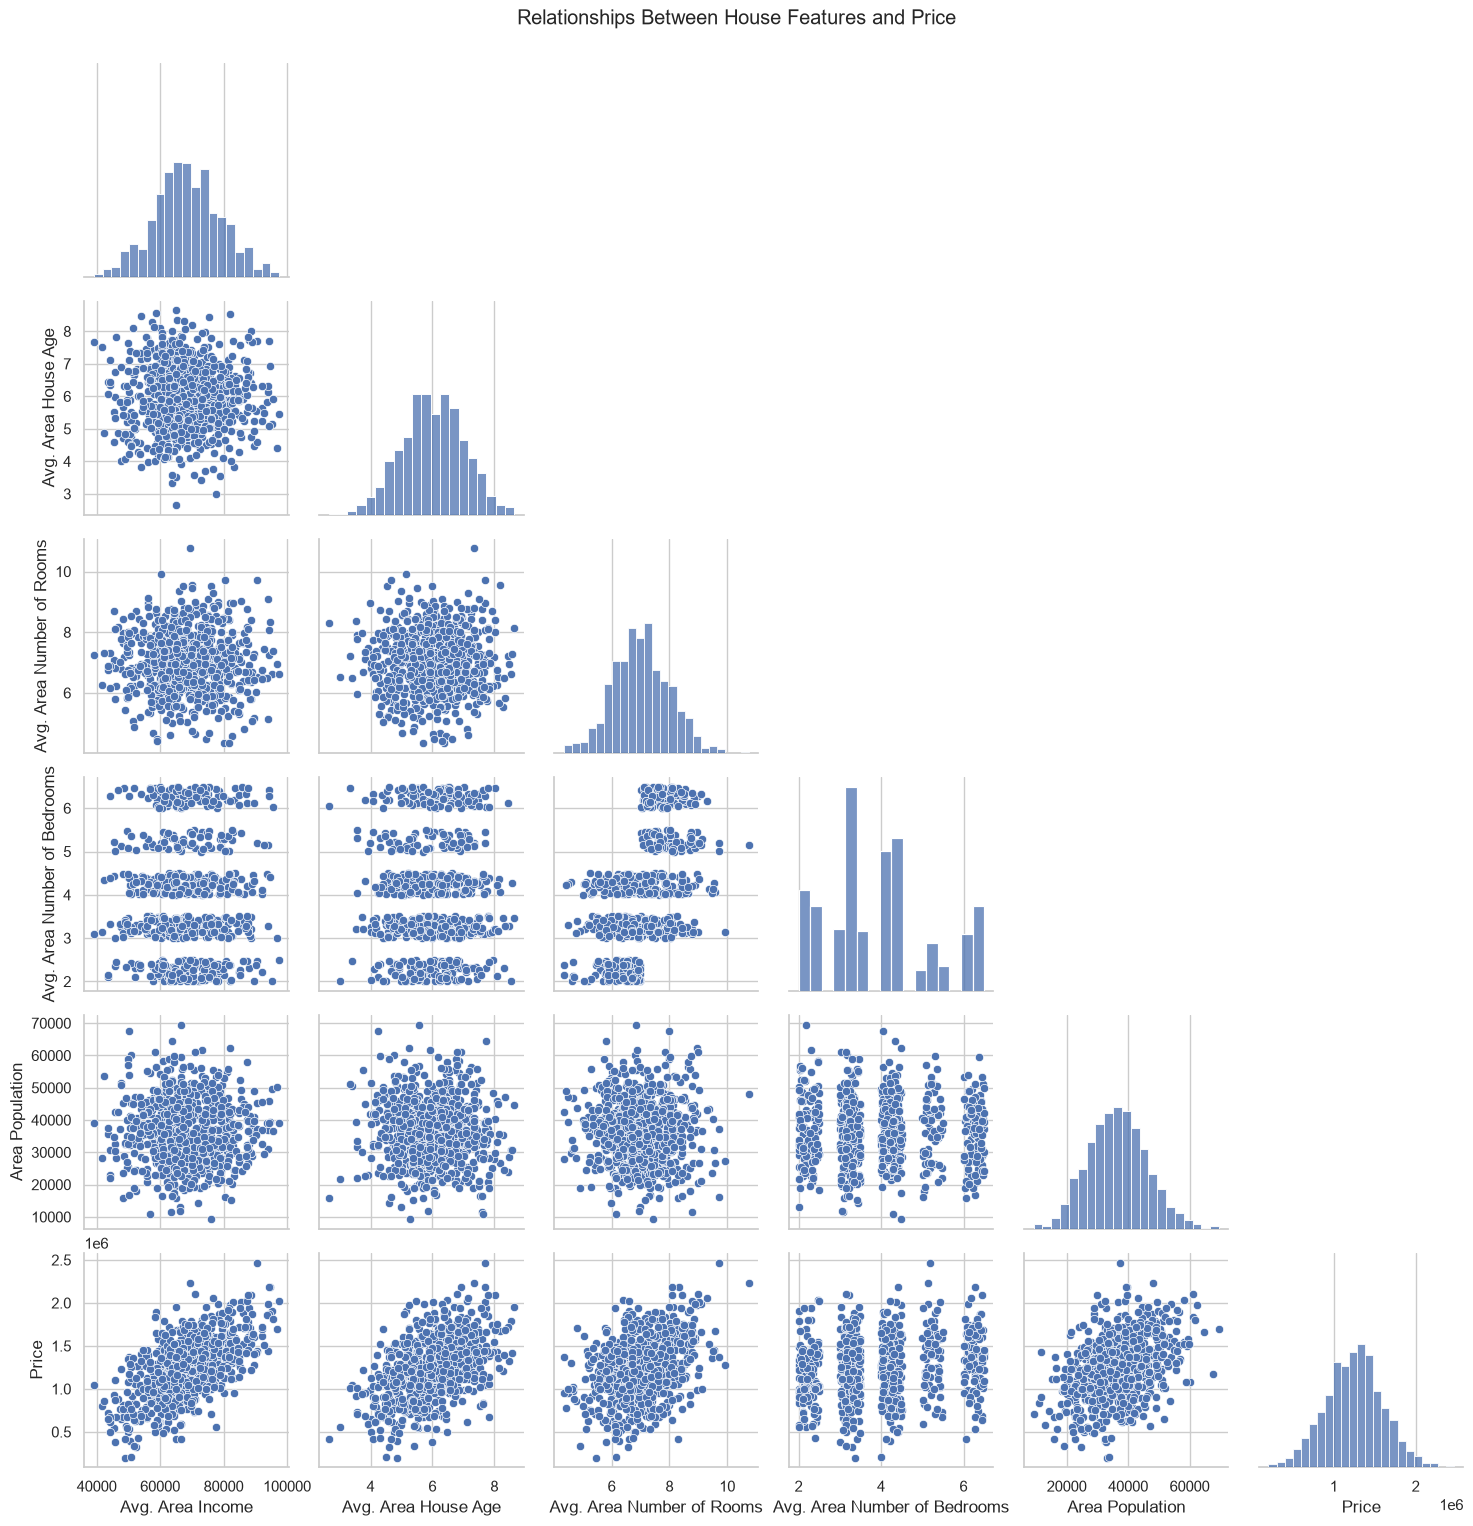

In [18]:
plot_sample = numeric_df.sample(
    n=min(750, len(numeric_df)),
    random_state=42
)

sns.pairplot(plot_sample, corner=True)
plt.suptitle("Relationships Between House Features and Price", y=1.02)
plt.show()

In [19]:
#Price distribution

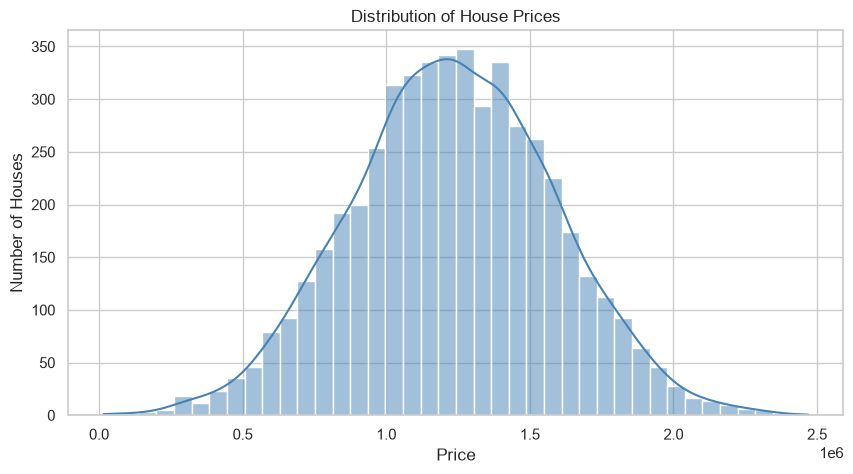

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=HouseDF,
    x="Price",
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.show()

In [21]:
#Correlation heatmap

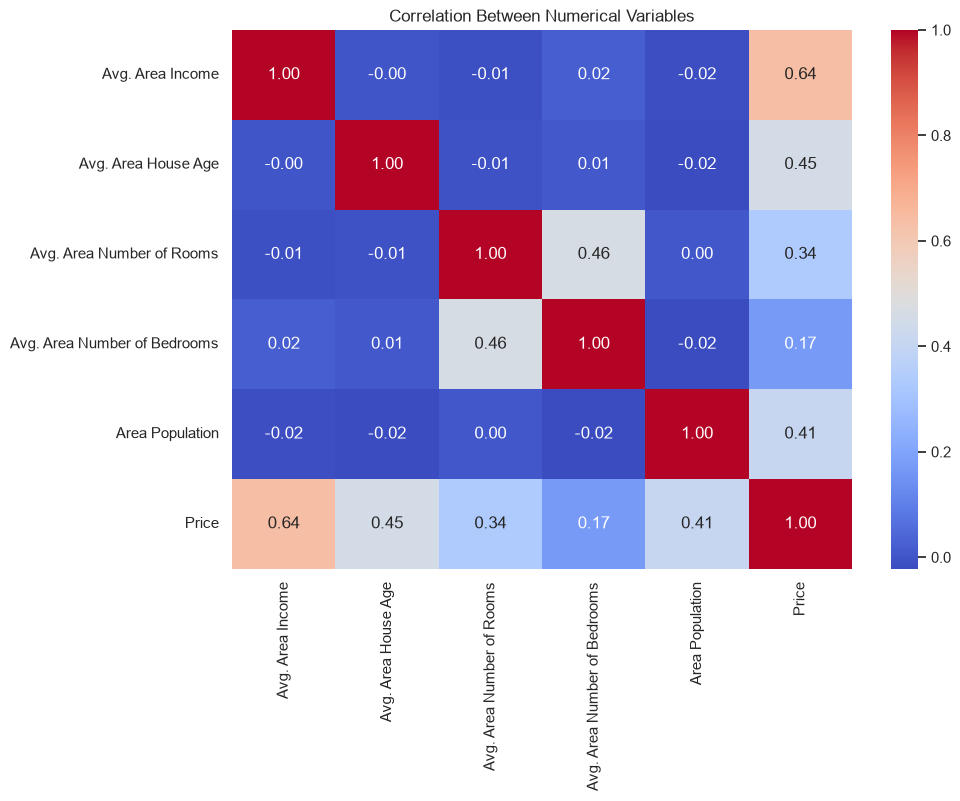

In [22]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")
plt.show()

In [23]:
#Define features and target

In [24]:
feature_columns = [
    "Avg. Area Income",
    "Avg. Area House Age",
    "Avg. Area Number of Rooms",
    "Avg. Area Number of Bedrooms",
    "Area Population"
]

target_column = "Price"

X = HouseDF[feature_columns]
y = HouseDF[target_column]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

X.head()

Feature matrix shape: (5000, 5)
Target vector shape: (5000,)


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.458574,5.682861,7.009188,4.09,23086.800503
1,79248.642455,6.002900,6.730821,3.09,40173.072174
2,61287.067179,5.865890,8.512727,5.13,36882.159400
3,63345.240046,7.188236,5.586729,3.26,34310.242831
4,59982.197226,5.040555,7.839388,4.23,26354.109472


In [25]:
#Split training and test data

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (4000, 5)
Testing features: (1000, 5)


In [27]:
#Create and train the Linear Regression model

In [28]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [29]:
#Make predictions

In [30]:
y_pred = linear_model.predict(X_test)

predictions_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred,
    "Residual": y_test.values - y_pred
})

predictions_df.head(10)

,Actual Price,Predicted Price,Residual
0,1.339096e+06,1.308588e+06,30508.150248
1,1.251794e+06,1.237037e+06,14756.949343
2,1.340095e+06,1.243429e+06,96665.625899
3,1.431508e+06,1.228900e+06,202607.409824
4,1.042374e+06,1.063321e+06,-20947.383012
5,1.555321e+06,1.544058e+06,11262.449653
6,1.250882e+06,1.094775e+06,156107.586827
7,1.039381e+06,8.332847e+05,206095.999087
8,8.324752e+05,7.884129e+05,44062.333228
9,1.420648e+06,1.469715e+06,-49066.585287


In [31]:
#Model evaluation metrics

In [32]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 80,879.10
Mean Squared Error (MSE): 10,089,009,300.89
Root Mean Squared Error (RMSE): 100,444.06
R² Score: 0.9180


In [33]:
#Actual vs predicted prices

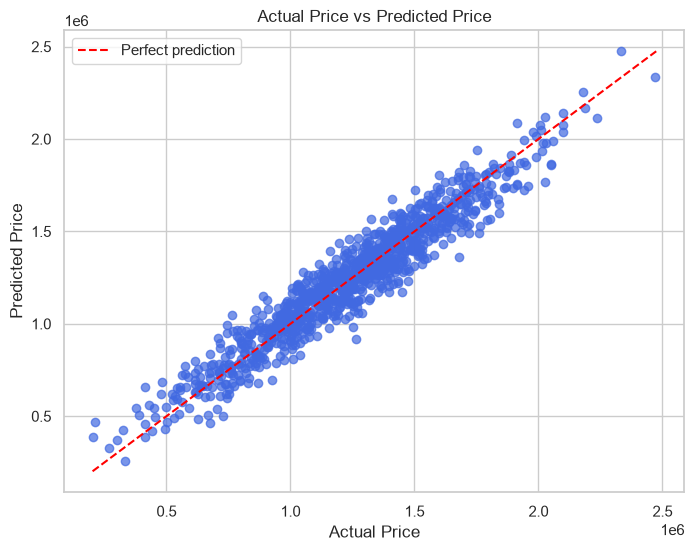

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7, color="royalblue")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.title("Actual Price vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()

In [35]:
#Residual distribution

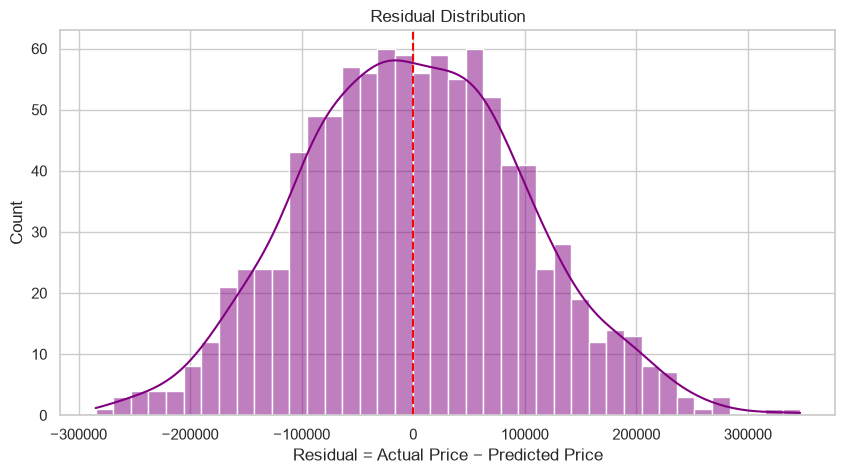

In [36]:
plt.figure(figsize=(10, 5))

sns.histplot(
    predictions_df["Residual"],
    bins=40,
    kde=True,
    color="purple"
)

plt.axvline(0, color="red", linestyle="--")
plt.title("Residual Distribution")
plt.xlabel("Residual = Actual Price − Predicted Price")
plt.ylabel("Count")
plt.show()

In [37]:
#Residual plot

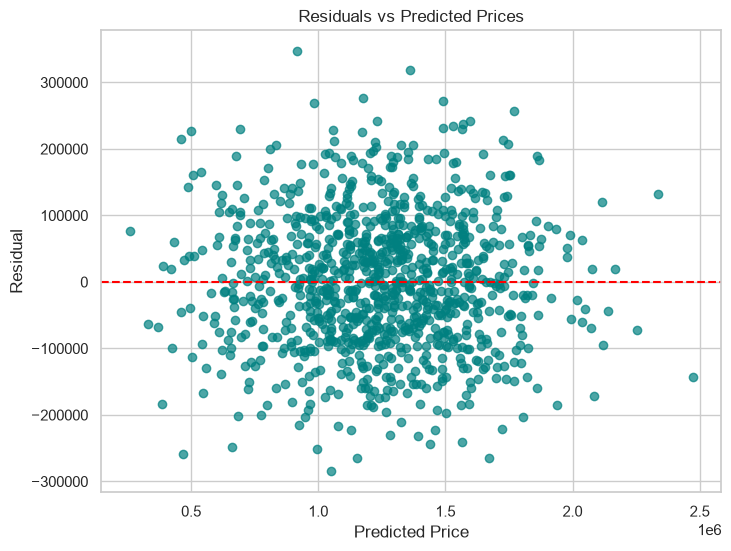

In [38]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, predictions_df["Residual"], alpha=0.7, color="teal")
plt.axhline(0, color="red", linestyle="--")

plt.title("Residuals vs Predicted Prices")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.show()

In [39]:
#Intercept and coefficients

In [40]:
print(f"Model intercept: {linear_model.intercept_:,.2f}")

coefficients_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients_df = coefficients_df.sort_values(
    by="Coefficient",
    key=lambda values: values.abs(),
    ascending=False
)

coefficients_df

Model intercept: -2,635,072.90


,Feature,Coefficient
1,Avg. Area House Age,164666.480722
2,Avg. Area Number of Rooms,119624.012232
3,Avg. Area Number of Bedrooms,2440.377611
0,Avg. Area Income,21.652206
4,Area Population,15.270313


In [41]:
#Visualize feature coefficients

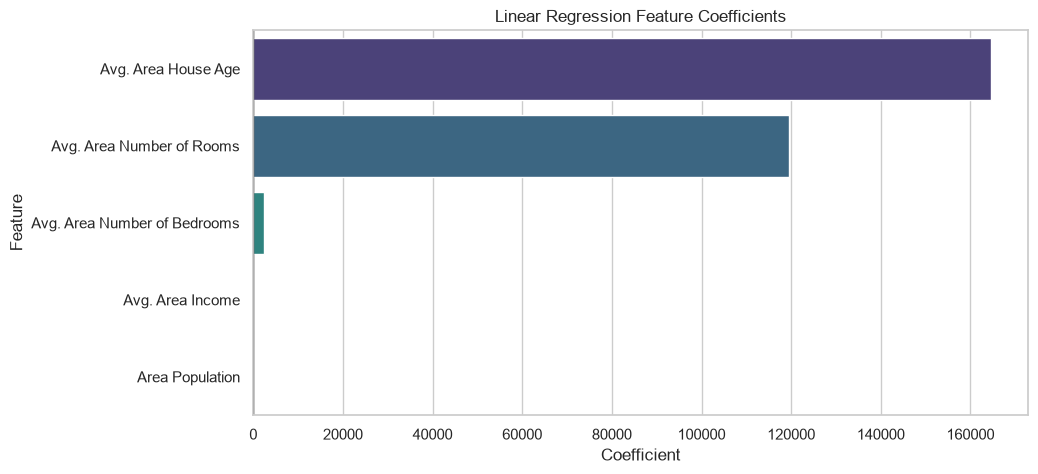

In [42]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=coefficients_df,
    x="Coefficient",
    y="Feature",
    hue="Feature",
    legend=False,
    palette="viridis"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Linear Regression Feature Coefficients")
plt.show()

In [43]:
#5-fold cross-validation

In [44]:
cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse_scores = -cv_scores

print("Cross-validation RMSE scores:")
print(np.round(cv_rmse_scores, 2))

print(f"\nMean CV RMSE: {cv_rmse_scores.mean():,.2f}")
print(f"Standard Deviation: {cv_rmse_scores.std():,.2f}")

Cross-validation RMSE scores:
[100434.58 103576.59  99305.67 100877.72 102055.71]

Mean CV RMSE: 101,250.05
Standard Deviation: 1,459.18


In [45]:
#Predict price for a new house

In [46]:
new_house = pd.DataFrame([{
    "Avg. Area Income": 70000,
    "Avg. Area House Age": 6.0,
    "Avg. Area Number of Rooms": 7.0,
    "Avg. Area Number of Bedrooms": 4.0,
    "Area Population": 35000
}])

new_house_prediction = linear_model.predict(new_house)[0]

print(f"Predicted house price: ${new_house_prediction:,.2f}")

Predicted house price: $1,250,170.95


In [47]:
#Save test-set predictions

In [48]:
output_file = "house_price_predictions.csv"

predictions_df.to_csv(output_file, index=False)

print(f"Predictions saved successfully as: {output_file}")

Predictions saved successfully as: house_price_predictions.csv


In [49]:
#Final conclusion

In [50]:
print("----- FINAL MODEL SUMMARY -----")
print(f"R² Score: {r2:.4f}")
print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"Average Cross-Validation RMSE: ${cv_rmse_scores.mean():,.2f}")

print("\nConclusion:")
print(
    "The Linear Regression model predicts house prices using five numerical features. "
    "A higher R² score and lower RMSE indicate better prediction performance."
)

----- FINAL MODEL SUMMARY -----
R² Score: 0.9180
MAE: $80,879.10
RMSE: $100,444.06
Average Cross-Validation RMSE: $101,250.05

Conclusion:
The Linear Regression model predicts house prices using five numerical features. A higher R² score and lower RMSE indicate better prediction performance.
